# Detecção de Fraudes em Transações de Cartão de Crédito

Projeto de Machine Learning para identificação de transações fraudulentas em uma base de dados de cartões de crédito.

O projeto aborda o problema de desbalanceamento das classes, comparando modelos de classificação por meio de métricas como precisão, recall e F1-score.

### Modelos utilizados

- Regressão Logística
- Random Forest
- XGBoost

### Etapas

1. Exploração dos dados
2. Preparação dos dados
3. Treinamento dos modelos
4. Avaliação
5. Ajuste do limiar de decisão
6. Explicabilidade com SHAP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve
)

from xgboost import XGBClassifier

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

print("Dataset carregado com sucesso!")

Dataset carregado com sucesso!


In [3]:
print("Dimensões da base:", df.shape)

display(df.head())

Dimensões da base: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [7]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


In [8]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X:", X.shape)
print("y:", y.shape)

X: (284807, 30)
y: (284807,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (227845, 30)
Teste: (56962, 30)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [11]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

modelo_logistico.fit(X_train, y_train)
y_pred_logistico = modelo_logistico.predict(X_test)

In [12]:
from sklearn.metrics import classification_report

print(

    classification_report(
        y_test,
        y_pred_logistico,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



In [13]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9605    0.7449    0.8391        98

    accuracy                         0.9995     56962
   macro avg     0.9800    0.8724    0.9194     56962
weighted avg     0.9995    0.9995    0.9995     56962



In [14]:
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
modelo_xgb.fit(X_train, y_train)
y_pred_xgb = modelo_xgb.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9998    0.9995    0.9996     56864
           1     0.7368    0.8571    0.7925        98

    accuracy                         0.9992     56962
   macro avg     0.8683    0.9283    0.8960     56962
weighted avg     0.9993    0.9992    0.9993     56962



In [15]:
probabilidades_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

print(probabilidades_xgb[:10])

[1.9751961e-04 1.3400319e-04 2.1909175e-03 1.0703851e-04 4.2758468e-03
 1.3629549e-04 6.4643471e-05 3.9908151e-05 2.4463621e-04 1.4158325e-04]


In [16]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

resultados_threshold = []

for threshold in thresholds:

    previsoes = (
        probabilidades_xgb >= threshold
    ).astype(int)

    resultados_threshold.append({
        "Threshold": threshold,
        "Precisão": precision_score(y_test, previsoes),
        "Recall": recall_score(y_test, previsoes),
        "F1-Score": f1_score(y_test, previsoes)
    })

df_threshold = pd.DataFrame(resultados_threshold)

display(
    df_threshold.style.format({
        "Threshold": "{:.1f}",
        "Precisão": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

,Threshold,Precisão,Recall,F1-Score
0,0.1,0.3826,0.8980,0.5366
1,0.2,0.5059,0.8776,0.6418
2,0.3,0.6071,0.8673,0.7143
3,0.4,0.6774,0.8571,0.7568
4,0.5,0.7368,0.8571,0.7925
5,0.6,0.7905,0.8469,0.8177
6,0.7,0.8617,0.8265,0.8438
7,0.8,0.8791,0.8163,0.8466
8,0.9,0.8876,0.8061,0.8449


## Ajuste do limiar de decisão

O XGBoost foi avaliado utilizando diferentes limiares de decisão. O aumento do threshold elevou a precisão, mas reduziu gradualmente o recall.

Entre os valores testados, o threshold de 0,8 apresentou o maior F1-score (84,66%), com precisão de 87,91% e recall de 81,63%.

Assim, o threshold de 0,8 foi utilizado como referência na análise final, buscando um equilíbrio entre a identificação de fraudes e a redução de falsos positivos.

In [17]:
import pandas as pd

importancias = pd.DataFrame({
    "Variavel": X_train.columns,
    "Importancia": modelo_xgb.feature_importances_
})

importancias = importancias.sort_values(
    "Importancia",
    ascending=False
)

display(importancias.head(15))

,Variavel,Importancia
14,V14,0.444941
4,V4,0.057188
10,V10,0.051685
12,V12,0.036226
29,Amount,0.032887
26,V26,0.026863
20,V20,0.026746
8,V8,0.025008
13,V13,0.021588
19,V19,0.019346


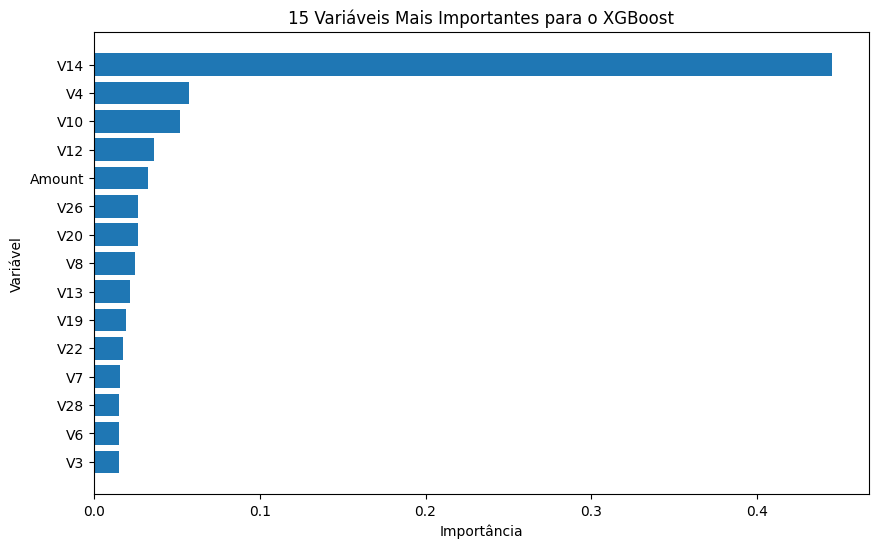

In [18]:
top_15 = importancias.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_15["Variavel"][::-1],
    top_15["Importancia"][::-1]
)

plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("15 Variáveis Mais Importantes para o XGBoost")

plt.show()

In [19]:
!pip install shap -q
import shap

X_shap = X_test.sample(
    1000,
    random_state=42
)

In [20]:
explainer = shap.TreeExplainer(modelo_xgb)

shap_values = explainer.shap_values(X_shap)


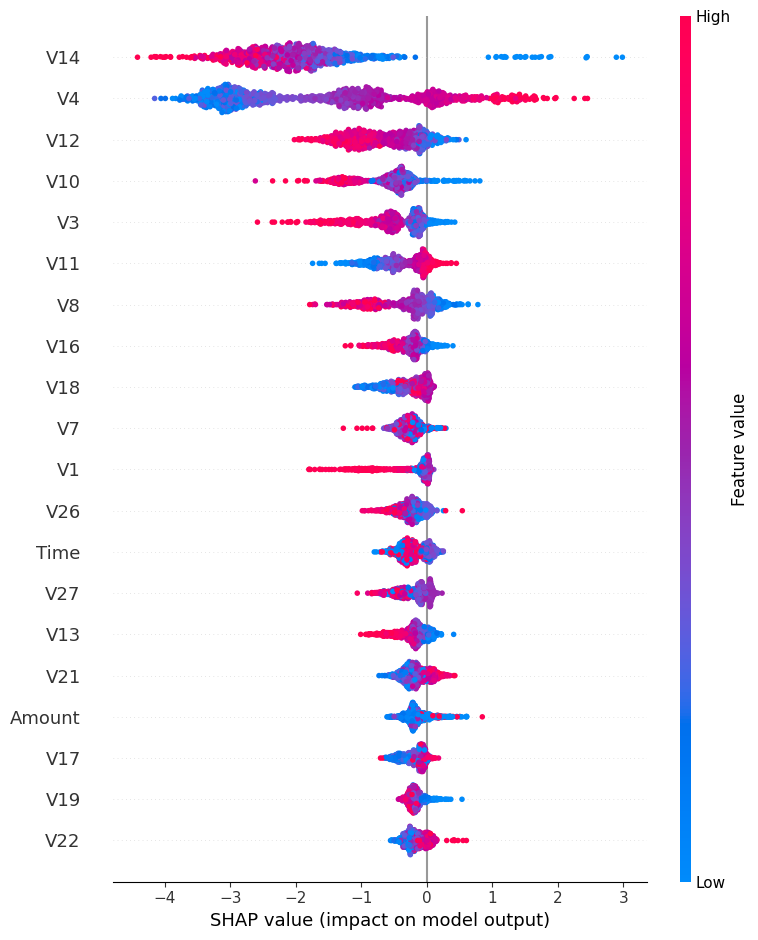

In [21]:
shap.summary_plot(
    shap_values,
    X_shap
)

### Interpretação do SHAP

O gráfico SHAP apresenta as principais variáveis que influenciaram as previsões do modelo XGBoost.

A variável V14 apresentou o maior impacto global nas previsões, seguida por V4, V12, V10, V3 e V11. A posição horizontal dos pontos representa o impacto da variável na saída do modelo, enquanto as cores indicam os valores das respectivas características.

É importante destacar que o SHAP representa a contribuição das variáveis para as previsões do modelo, não uma relação de causalidade. Assim, uma variável com maior impacto não significa necessariamente que ela seja a causa da fraude.

Probabilidade estimada de fraude: 0.9999032


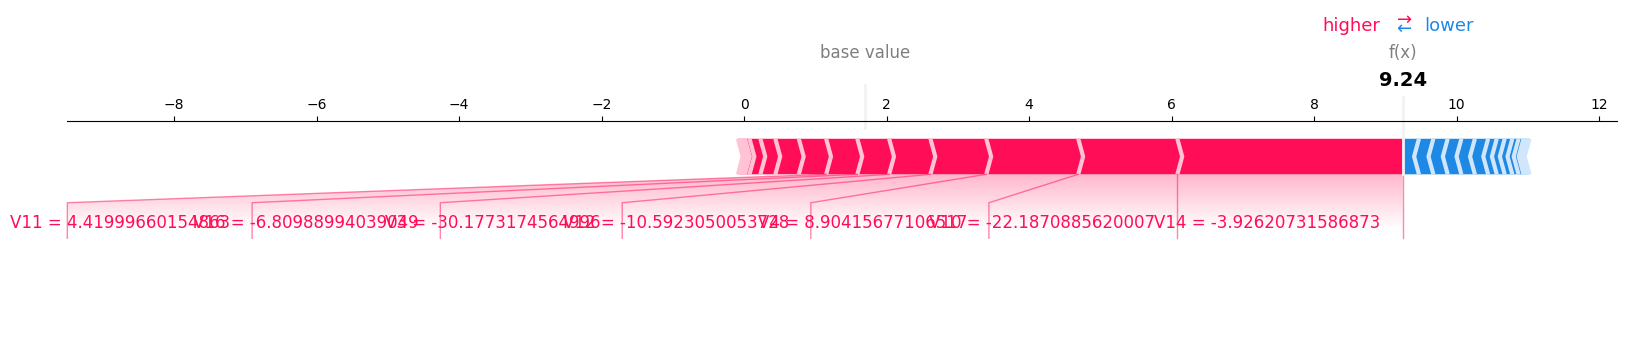

In [22]:
probabilidades = modelo_xgb.predict_proba(X_test)[:, 1]

indice_fraude = np.argmax(probabilidades)

transacao = X_test.iloc[[indice_fraude]]

print(
    "Probabilidade estimada de fraude:",
    probabilidades[indice_fraude]
)
shap_transacao = explainer.shap_values(transacao)
shap.force_plot(
    explainer.expected_value,
    shap_transacao[0],
    transacao.iloc[0],
    matplotlib=True
)

Probabilidade de fraude: 0.9993394


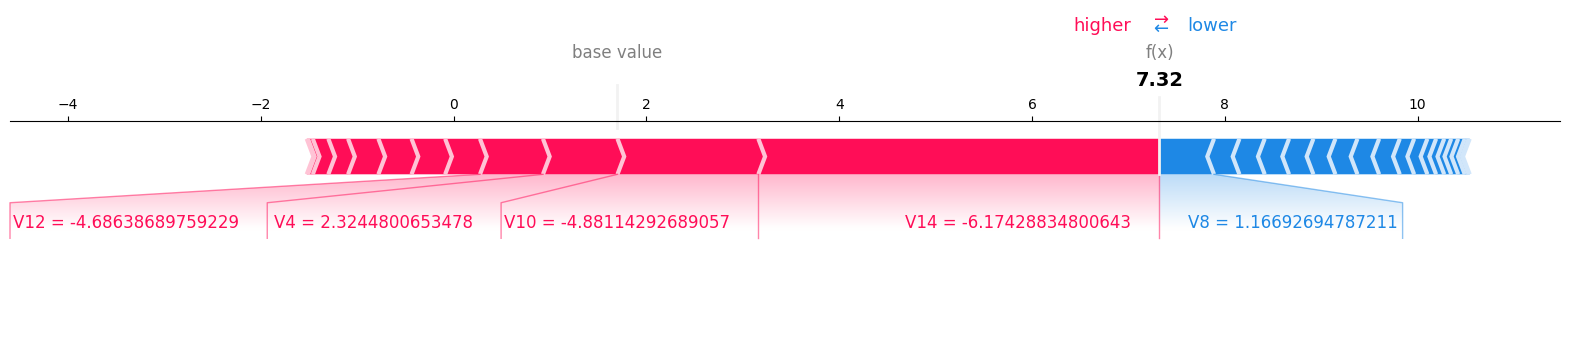

In [23]:
indice_fraude = y_test[y_test == 1].index[0]

transacao = X_test.loc[[indice_fraude]]

print(
    "Probabilidade de fraude:",
    modelo_xgb.predict_proba(transacao)[0, 1]
)

shap_transacao = explainer.shap_values(transacao)

shap.force_plot(
    explainer.expected_value,
    shap_transacao[0],
    transacao.iloc[0],
    matplotlib=True
)

### Explicação de uma transação individual

Além da análise global, o SHAP foi utilizado para explicar uma transação individual.

A visualização apresenta como diferentes variáveis contribuíram para a saída do modelo. As contribuições em vermelho aumentaram a saída da previsão, enquanto as contribuições em azul atuaram no sentido contrário.

Nesta transação, as variáveis V12, V4, V10 e V14 apresentaram contribuições relevantes para a saída do modelo, enquanto V8 contribuiu no sentido oposto.

O resultado demonstra que a classificação realizada pelo XGBoost é baseada na combinação de diversas características da transação, e não em uma única variável isolada.

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

resultados = []

modelos = {
    "Regressão Logística": y_pred_logistico,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for nome, previsoes in modelos.items():
    resultados.append({
        "Modelo": nome,
        "Precisão": precision_score(y_test, previsoes),
        "Recall": recall_score(y_test, previsoes),
        "F1-Score": f1_score(y_test, previsoes)
    })

df_resultados = pd.DataFrame(resultados)

display(
    df_resultados.style.format({
        "Precisão": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

,Modelo,Precisão,Recall,F1-Score
0,Regressão Logística,0.0610,0.9184,0.1144
1,Random Forest,0.9605,0.7449,0.8391
2,XGBoost,0.7368,0.8571,0.7925


## Comparação dos modelos

Os três modelos apresentaram comportamentos diferentes na detecção de fraudes.

A Regressão Logística apresentou o maior recall entre os modelos avaliados, identificando 91,84% das fraudes, porém apresentou baixa precisão, resultando em muitos falsos positivos.

O Random Forest apresentou alta precisão de 96,05%, mas seu recall foi de 74,49%, deixando de identificar uma parcela maior das fraudes.

O XGBoost apresentou um equilíbrio entre precisão e recall, com precisão de 73,68%, recall de 85,71% e F1-Score de 79,25%.

Essa comparação demonstra a importância de utilizar métricas específicas para a classe de fraude em vez de considerar apenas a acurácia.

In [25]:
threshold_final = 0.8

y_pred_xgb_threshold = (
    probabilidades_xgb >= threshold_final
).astype(int)

In [26]:
threshold_final = 0.8

y_pred_xgb_threshold = (
    probabilidades_xgb >= threshold_final
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_xgb_threshold,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9997     56864
           1     0.8791    0.8163    0.8466        98

    accuracy                         0.9995     56962
   macro avg     0.9394    0.9081    0.9232     56962
weighted avg     0.9995    0.9995    0.9995     56962



## Resultado após ajuste do threshold

O XGBoost também foi avaliado utilizando diferentes thresholds de decisão.

Entre os valores testados, o threshold de 0,8 apresentou o maior F1-Score, com 84,66%, além de precisão de 87,91% e recall de 81,63%.

Esse ajuste aumentou a precisão em relação ao threshold padrão de 0,5, porém reduziu o recall. Portanto, a escolha do threshold representa um compromisso entre identificar mais fraudes e reduzir falsos positivos.

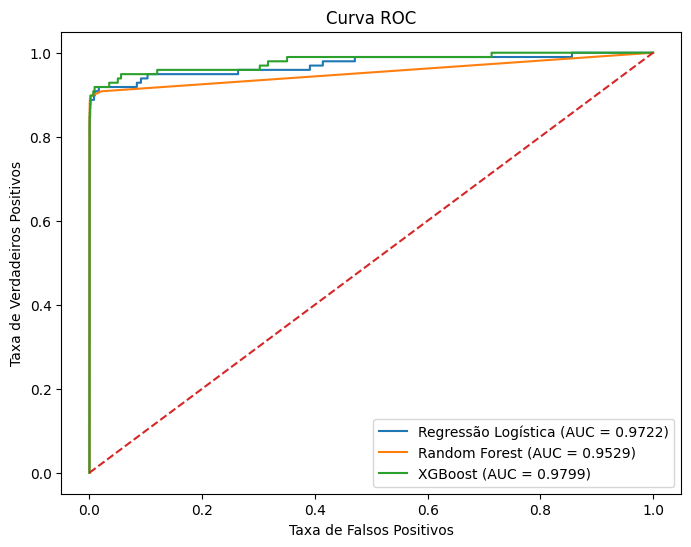

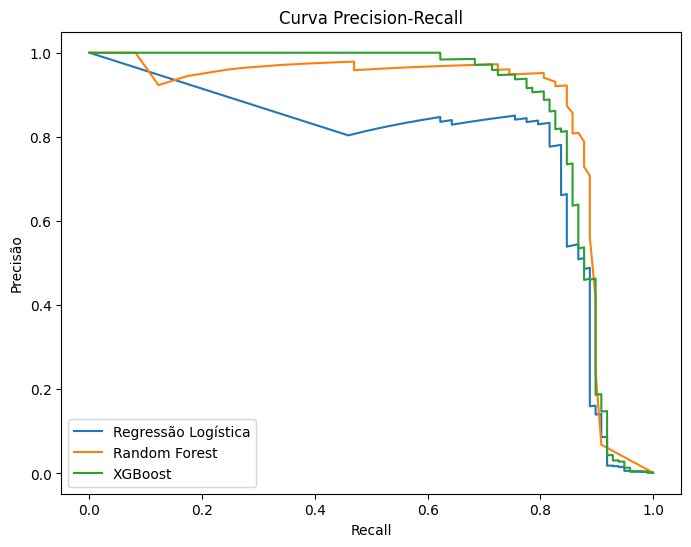

In [27]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

prob_logistico = modelo_logistico.predict_proba(X_test)[:, 1]
prob_rf = modelo_rf.predict_proba(X_test)[:, 1]
prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, prob_logistico)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_xgb)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label=f"Regressão Logística (AUC = {auc_log:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC")
plt.legend()

plt.show()

precision_log, recall_log, _ = precision_recall_curve(
    y_test,
    prob_logistico
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    prob_rf
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_log,
    precision_log,
    label="Regressão Logística"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precision-Recall")
plt.legend()

plt.show()

## Curvas ROC e Precision-Recall

As curvas ROC e Precision-Recall foram utilizadas para complementar a avaliação dos modelos.

A curva ROC apresenta a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos para diferentes thresholds.

Já a curva Precision-Recall é especialmente relevante neste projeto devido ao forte desbalanceamento da base, permitindo analisar diretamente o comportamento do modelo na identificação da classe de fraude.

Essas curvas complementam as métricas de precisão, recall e F1-Score apresentadas anteriormente.

# Conclusão

Este projeto apresentou um pipeline de Machine Learning para detecção de fraudes em transações de cartão de crédito.

A base possui um forte desbalanceamento entre transações legítimas e fraudulentas, com aproximadamente 0,17% das transações pertencentes à classe de fraude. Por esse motivo, a acurácia isoladamente não foi utilizada como principal métrica de avaliação.

Foram treinados três modelos: Regressão Logística, Random Forest e XGBoost. Os modelos foram comparados utilizando precisão, recall e F1-Score para a classe de fraude.

A Regressão Logística apresentou alto recall, mas baixa precisão, enquanto o Random Forest apresentou alta precisão e menor recall. O XGBoost apresentou um equilíbrio entre essas métricas.

Também foi realizado um ajuste do threshold do XGBoost. Entre os valores testados, o threshold de 0,8 apresentou o maior F1-Score, alcançando aproximadamente 84,66% de F1-Score, 87,91% de precisão e 81,63% de recall.

Por fim, a utilização do SHAP permitiu interpretar as decisões do XGBoost, identificando as variáveis que mais contribuíram para as previsões do modelo e permitindo analisar individualmente uma transação.

O projeto demonstra que, em problemas de detecção de fraude, é necessário considerar o desbalanceamento da base e analisar diferentes métricas e thresholds para compreender o comportamento do modelo.